# Dipole-portal HNL sensitivity from the forward neutrino flux

Same beam, detector, and signal chain as the mixing-portal study
(`hnl_sensitivity.ipynb`), but for the **transition magnetic dipole portal**
$\mathcal{L} \supset d_{\mu N}\, (\bar\nu_\mu \sigma^{\mu\nu} N) F_{\mu\nu}$:

1. **Upscattering** $\nu\, A \to N\, A$ — coherent Primakoff off the nucleus,
   $\sigma \propto \alpha\, Z^2 d^2 \ln(Q^2_{\rm max}/Q^2_{\rm min})$ (leading log,
   `hnl_tools.DipolePortal`).
2. **Propagation** — the boosted $N$ travels through gap / gas / rock.

1. **Forward flux** at the benchmark detector, 5 km downstream/upstream.
2. **Dipole ingredients** — coherent / p-elastic / DIS upscattering (DarkNews-exact,
   validated channel by channel) and the HNL decay length.
3. **Signal scans** over $(m_N, d)$ for both the **muon** and **electron** couplings.
4. **Sensitivity planes**, $d_{\mu N}$ and $d_{eN}$ side by side.
5. **Scattering on electrons** — the $\nu$-$e$ analysis with correlated systematics.
6. Notes.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

import mint
mint.xsecs.use_backend("alfonso")   # tabulated cross sections; the
# normalization used throughout MINT. The "ct18" backend recomputes these
# at LO from CT18NNLO PDFs and runs 10-15% lower in CC; see notebook 0.
from mint import const
from mint import detector_tools as dt
from mint import plot_tools as pt
from mint.MuC import MuDecaySimulator

import hnl_tools as hnl        # local module: physics_studies/hnl_tools.py
import dipole_limits as dlim   # local module: existing d_{mu N} limits

## 1. Forward neutrino flux at 5 km (from the beam simulation)

Identical to the mixing study: the packaged 10 TeV IR lattice, one full injection
period with beam dynamics on, 1 year of injections, $\mu^+ \to \bar\nu_\mu$.

In [2]:
nuflavor = "numubar"
ring, sim, injections_per_year = mint.beams.standard_beam(nuflavor, n_evals=5e5)
print(f"Lattice: {ring.s(1)/1e5:.2f} km of the {ring.total_circumference/1e5:.0f} km machine "
      f"({ring.s(1)/ring.total_circumference:.1%} covered)")
print(f"Injections/year: {injections_per_year:.2e}")

# Exposure: 10 years, both beams, identical detectors (see 3_hnl_sensitivity)
N_YEARS = 10
N_DETECTORS = 2
injections_per_year *= N_YEARS * N_DETECTORS

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


Lattice: 1.46 km of the 10 km machine (14.6% covered)
Injections/year: 5.02e+07


In [3]:
det = mint.detectors.load("benchmark_5km")
DIST, DET_R, GAP = det.dist, det.radius, det.gap
DET_L = det.fiducial_length          # active gas = the decay volume
gas, TARGET_MAT = det.gas, det.vertex_mat
N_TARGETS, TARGET_THICK = det.n_plates, det.foil_thick
target_positions = np.linspace(det.Z_VTX0, det.Z_VTX1, det.n_plates,
                               endpoint=False)
targets = [(det.Z_VTX0, det.Z_VTX1 - det.Z_VTX0, det.vertex_mat)]
print(det)

Detector('benchmark_5km': 75.5 m long, R = 1.28-2.41 m, 38 m of 5 bar Ar, vertex tracker 24x5 cm r<50 cm at 5.00 km)


## 2. Dipole ingredients: coherent cross section and decay length

The dipole decay is electromagnetic: at the same coupling strength the lifetime is
orders of magnitude shorter than the weak mixing-portal decay, so the sensitivity
lives at much smaller couplings and lower masses (MeV--GeV).

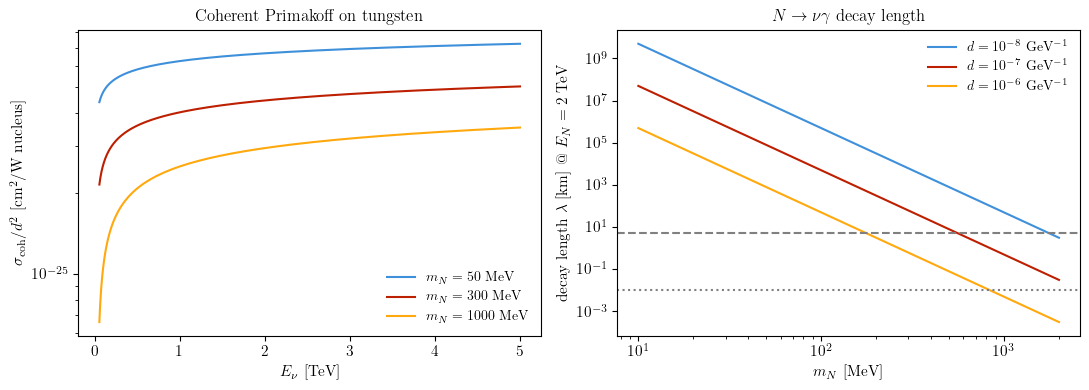

In [4]:
Egrid = np.geomspace(50, 5e3, 200)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# coherent Primakoff cross section on tungsten, shown at d = 1 GeV^-1
for mN in [0.05, 0.3, 1.0]:
    ax[0].plot(Egrid/1e3, hnl.dipole_coherent_xsec(Egrid, mN, 1.0, dt.W.Z, dt.W.A),
               label=fr"$m_N={mN*1e3:.0f}$ MeV")
ax[0].set_xlabel(r"$E_\nu$ [TeV]")
ax[0].set_ylabel(r"$\sigma_{\rm coh}/d^2$  [cm$^2$/W nucleus]")
ax[0].set_yscale("log"); ax[0].legend(frameon=False)
ax[0].set_title("Coherent Primakoff on tungsten")

# lab decay length vs mass at E_N = 2 TeV
E_N = 2000.0
mgrid = np.geomspace(0.01, 2.0, 200)
for d in [1e-8, 1e-7, 1e-6]:
    lam = hnl.decay_length(E_N, mgrid, hnl.dipole_radiative_width(mgrid, d))
    ax[1].plot(mgrid*1e3, lam/1e5, label=fr"$d=10^{{{int(np.log10(d))}}}$ GeV$^{{-1}}$")
ax[1].axhline(0.01, ls=":", color="gray")   # 10 m fiducial in km
ax[1].axhline(5, ls="--", color="gray")     # 5 km baseline
ax[1].set_xlabel(r"$m_N$ [MeV]")
ax[1].set_ylabel(r"decay length $\lambda$ [km] @ $E_N=2$ TeV")
ax[1].set_xscale("log"); ax[1].set_yscale("log"); ax[1].legend(frameon=False)
ax[1].set_title(r"$N \to \nu\gamma$ decay length")
plt.tight_layout()

### Validation: upscattering cross sections by channel

Before the sensitivity: the production cross sections themselves, per **tungsten atom**,
at $d_{\mu N} = 10^{-6}$ GeV$^{-1}$ ($\sigma \propto d^2$). Solid: exact calculations —
DarkNews coherent and $p$-elastic (real form factors, convention $\mu_{\rm tr} = 2d$
pinned in `validate_dipole_xsecs.py`), PDF-convolved DIS (DarkNews DIS regime,
CT18NNLO, $Q^2 > 2$ GeV$^2$), and the exact electron cross section (Eq. (A.10) of
arXiv:2011.04751, $\times Z$ electrons/atom). Thin dashed: the leading-log estimates
used in the scan (coherent and DIS). Physics to check: the $Z^2$-coherent dominance
and its saturation, the electron channel's hard threshold
$E_\nu > m_N^2/2m_e$, and DIS growing with energy as the sea opens up.

In [5]:
# ---------------- validation: upscattering cross sections per channel ----------------
from DarkNews import phase_space as dn_ps
from DarkNews import pdf as dnpdf
from DarkNews import amplitudes as dn_amps
from DarkNews import pdg as dn_pdg
from DarkNews.nuclear_tools import NuclearTarget
from DarkNews.model import ThreePortalModel
from DarkNews.processes import UpscatteringProcess

D_VAL = 1e-6                              # reference coupling [GeV^-1]
E_grid_val = np.geomspace(10, 5e3, 30)
masses_val = [0.1, 1.0]
W_tgt = NuclearTarget("W184")
pdf_ct18 = dnpdf.mkPDF("CT18NNLO")


def dis_xsec_W(Enu, mN, Q2cut=2.0, nx=60, ny=60):
    """Exact dipole DIS cross section on W184 [cm^2/nucleus], Q2 > Q2cut."""
    mdl = ThreePortalModel(m4=mN, mu_tr_mu4=2 * D_VAL, mzprime=1.25)
    proc = UpscatteringProcess(nu_projectile=dn_pdg.numu, nu_upscattered=dn_pdg.neutrino4,
                               nuclear_target=W_tgt, scattering_regime="DIS",
                               TheoryModel=mdl, helicity="conserving")
    proc.target.pdf = pdf_ct18
    M = proc.target.mass
    xlo = dn_ps.dis_xmin(Enu, mN, M)
    if xlo >= 1.0:
        return 0.0
    xs = np.geomspace(max(xlo, 1e-6), 1.0, nx)
    dsdx = np.zeros_like(xs)
    for i, xv in enumerate(xs):
        ymin, ymax = dn_ps.dis_ylimits(Enu, xv, mN, M)
        ylo = max(max(float(ymin), 0.0), Q2cut / (2 * M * Enu * xv))
        if ylo >= ymax:
            continue
        ys = np.geomspace(ylo, float(ymax), ny)
        dsdx[i] = np.trapezoid(dn_amps.dis_diff_xsec_dxdy(Enu, np.full_like(ys, xv), ys, proc), ys)
    return np.trapezoid(dsdx, xs)


def electron_xsec(Enu, mN, n_nodes=300):
    """Exact total nu e- -> N e- cross section [cm^2/electron]."""
    lo, hi = hnl.dipole_electron_Te_limits(Enu, mN)
    lo, hi = float(lo), float(hi)
    if hi <= lo or hi <= 0:
        return 0.0
    Te = np.geomspace(max(lo, 1e-12) * 1.000001, hi * 0.999999, n_nodes)
    return np.trapezoid(hnl.dipole_electron_dsigma_dTe(Te, Enu, mN, D_VAL), Te)


channels_val = {}
for m in masses_val:
    coh = hnl.darknews_upscattering_xsec(E_grid_val, m, "dipole", "W184",
                                         regimes=("coherent",), ref_coupling=2 * D_VAL, NEVAL=1500)
    pel = hnl.darknews_upscattering_xsec(E_grid_val, m, "dipole", "W184",
                                         regimes=("p-el",), ref_coupling=2 * D_VAL, NEVAL=1500)
    dis = np.array([dis_xsec_W(E, m) for E in E_grid_val])
    ele = W_tgt.Z * np.array([electron_xsec(E, m) for E in E_grid_val])
    channels_val[m] = {"coh": coh, "pel": pel, "dis": dis, "ele": ele}
    print(f"m_N = {m:g} GeV: sigma(3 TeV) coh {coh[-2]:.2e} | p-el {pel[-2]:.2e} "
          f"| DIS {dis[-2]:.2e} | e- {ele[-2]:.2e} cm^2/atom")


m_N = 0.1 GeV: sigma(3 TeV) coh 1.26e-36 | p-el 2.05e-38 | DIS 1.91e-38 | e- 2.24e-38 cm^2/atom


m_N = 1 GeV: sigma(3 TeV) coh 6.86e-37 | p-el 1.28e-38 | DIS 1.86e-38 | e- 1.13e-38 cm^2/atom


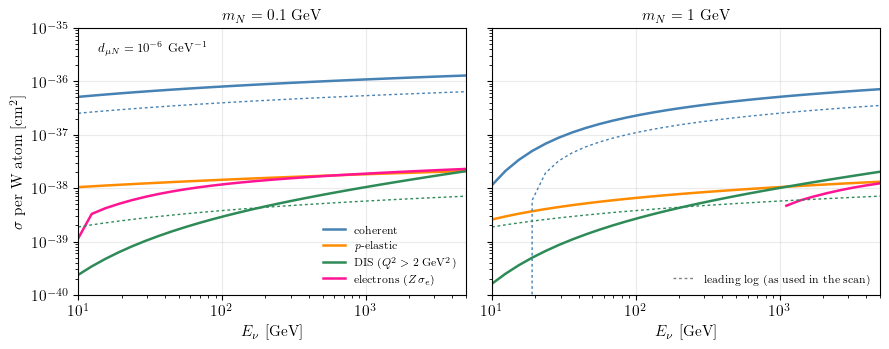

In [6]:
# ---------------- plot ----------------
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6), sharey=True)
colors_ch = {"coh": "steelblue", "pel": "darkorange", "dis": "seagreen", "ele": "deeppink"}
labels_ch = {"coh": "coherent", "pel": r"$p$-elastic",
             "dis": r"DIS ($Q^2 > 2$ GeV$^2$)", "ele": r"electrons ($Z\,\sigma_e$)"}

for ax, m in zip(axes, masses_val):
    for k in ["coh", "pel", "dis", "ele"]:
        y = np.asarray(channels_val[m][k])
        good = y > 0
        ax.plot(E_grid_val[good], y[good], color=colors_ch[k], lw=1.8, label=labels_ch[k])
    # leading-log estimates used in the scan
    ax.plot(E_grid_val, hnl.dipole_coherent_xsec(E_grid_val, m, D_VAL, W_tgt.Z, W_tgt.A),
            color=colors_ch["coh"], lw=1.0, ls=(0, (2, 2)))
    ax.plot(E_grid_val, W_tgt.A * hnl.dipole_dis_xsec(E_grid_val, m, D_VAL, W_tgt.Z, W_tgt.A, Q2_min=2.0),
            color=colors_ch["dis"], lw=1.0, ls=(0, (2, 2)))
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(E_grid_val[0], E_grid_val[-1])
    ax.set_xlabel(r"$E_\nu$ [GeV]")
    ax.set_title(rf"$m_N = {m:g}$ GeV", fontsize=11)
    ax.grid(True, which="major", ls="-", alpha=0.25)

axes[0].set_ylim(1e-40, 1e-35)
axes[0].set_ylabel(r"$\sigma$ per W atom [cm$^2$]")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
axes[1].legend([Line2D([], [], color="gray", lw=1.0, ls=(0, (2, 2)))],
               ["leading log (as used in the scan)"], frameon=False, fontsize=8, loc="lower right")
axes[0].annotate(r"$d_{\mu N} = 10^{-6}$ GeV$^{-1}$",
                 xy=(0.05, 0.95), xycoords="axes fraction", ha="left", va="top", fontsize=9)
fig.tight_layout()
fig.savefig("plots/hnl_dipole_xsec_validation.pdf", bbox_inches="tight", dpi=300)

## 3. Signal scans over $(m_N,\ d)$: muon and electron couplings

Three signal samples, defined by what is actually visible:

- **Single photon (rock + detector, merged):** coherent production leaves *no visible
  production vertex* (the nuclear recoil is sub-MeV), so rock- and detector-produced
  HNLs give the same signature -- a lone photon appearing in the gas -- and are counted
  as one sample (no displacement cut is possible without a production vertex). This
  carries the bulk of the rate ($Z^2$-coherent production over the full rock column)
  but is background-limited: event-by-event it cannot be told apart from
  $\nu$-induced single-shower events (coherent $\pi^0$, NC with only $\pi^0$s
  visible, ...).
- **DIS displaced vertex:** deep-inelastic production in the detector
  (`hnl_tools.DipoleDISPortal`, leading-log photon exchange off quarks, no $Z^2$
  coherence) deposits a hadronic recoil at the vertex, so the decay photon displaced
  $\geq 3$ cm from it is a clean, taggable topology.
- **$N \to \nu\gamma^* \to \nu e^+e^-$ (rock):** the Dalitz-like internal
  conversion (exact width, Eq. (B.5) of arXiv:2011.04751; BR $\sim 0.4\%$), gives a reconstructable displaced $e^+e^-$ vertex in the gas even for
  rock production.

**Production inputs (DarkNews everywhere).** All production cross sections in the scan
are the exact DarkNews calculations, tabulated per (mass, material) and cached on disk:
**elastic** = coherent + proton-elastic with real nuclear form factors on W184 (slabs),
Ar40 (gas), and Na23 (the closest nuclide to standard rock, $Z=11$; the rock's nucleus
density keeps its own $A=22$); **DIS** = PDF-convolved (CT18NNLO, $Q^2 > 2$ GeV$^2$) on
the same targets, with the $\mu_{\rm tr} = 2d$ convention applied throughout. The
analytic leading-log portals (`DipolePortal`, `DipoleDISPortal`) remain available for
quick estimates and are compared against these inputs in the validation figure above.

In [7]:
Lss_half = det.rock_start   # rock begins at 250 m (straight section ends at 180 m)
L_fid = det.fiducial_length   # 38 m of active gas = the decay volume
rock = dt.standard_rock

def flux_at(D):
    """Energies, annual weights and chords of the flux through the signal
    volume (vertex tracker + gas) with the front face at z = D [cm]."""
    return det.flux_with_chords(sim, exposure=injections_per_year, dist=D)

MIN_DISP = 3.0   # cm: in-detector production->decay displacement cut
PT_MIN = 0.0     # GeV: photon-pT cut for rock-produced HNLs (0 = off, as in the mixing plot)

m_N_grid = np.geomspace(0.01, 1e3, 60)     # GeV
d_grid = np.geomspace(1e-11, 1e-4, 100)    # GeV^-1
distances = [5e5]                          # detector front face at 5 km
colors = ["steelblue"]

scan_results = {}
for D, c in zip(distances, colors):
    E, w, ch = flux_at(D)
    # Bin the flux before scanning. The signal is an integral over the spectrum,
    # so 60 quadrature points reproduce the 33k-event sum to 4 decimals while
    # making the (mass, coupling) grid ~60x cheaper.
    E, w = dt.bin_flux(E, w, n_bins=60)
    print(f"D = {D/1e5:.0f} km: {w.sum():.3e} nu/year through the face ({len(E)} MC events)")
    geom = hnl.BeamDumpGeometry(Lss_half, D, L_fid, rock=rock,
                                fiducial_produces=False, gap_cm=GAP)

    N_only = np.zeros((m_N_grid.size, d_grid.size))
    N_rock = np.zeros_like(N_only)
    N_dis = np.zeros_like(N_only)
    for i, m in enumerate(m_N_grid):
        if i % 10 == 0:
            print(f"  tabulating DarkNews xsecs: m_N = {m:.3g} GeV ({i+1}/{m_N_grid.size})")
        # DarkNews-everything: exact elastic (coherent + p-elastic, real nuclear
        # form factors) per material -- W184 slabs, Ar40 gas, Na23 as the
        # standard-rock proxy -- and exact PDF-convolved DIS (CT18NNLO,
        # Q^2 > 2 GeV^2). Tabulations are disk-cached (.dn_dipole_xsec_cache.npz).
        p = hnl.DarkNewsMultiPortal(m, materials=[gas, TARGET_MAT, rock])
        p_dis = hnl.DarkNewsDISPortal(m, materials=[gas, TARGET_MAT])
        for j, d in enumerate(d_grid):
            # coherent production has no visible vertex -> no displacement cut;
            # detector- and rock-produced single photons form ONE merged sample
            N_only[i, j] = hnl.signal_events_detector(
                E, w, p, d, det, min_displacement_cm=0.0)
            N_rock[i, j] = hnl.signal_events_beamdump(E, w, p, d, geom, pT_min=PT_MIN)
            # visible-vertex sample: DIS production, photon displaced >= MIN_DISP
            N_dis[i, j] = hnl.signal_events_detector(
                E, w, p_dis, d, det, min_displacement_cm=MIN_DISP)

    # N -> nu l+ l- (internal conversion) from rock production: same rate x BR,
    # using the EXACT widths of Jodlowski & Trojanowski (arXiv:2011.04751, Eq. B.5)
    N_ee = N_rock * hnl.dipole_pair_br(m_N_grid, const.m_e)[:, None]
    N_mm = N_rock * hnl.dipole_pair_br(m_N_grid, const.m_mu)[:, None]

    scan_results[D] = {"color": c, "N_only": N_only, "N_rock": N_rock,
                       "N_dis": N_dis, "N_ee": N_ee, "N_mm": N_mm,
                       "N_clean": N_dis + N_ee + N_mm,
                       "N_tot": N_only + N_rock}

mN_2D, d_2D = np.meshgrid(m_N_grid, d_grid, indexing="ij")
print("Event-rate grids ready:", [f"{D/1e5:.0f} km" for D in scan_results])

D = 5 km: 4.448e+19 nu/year through the face (60 MC events)
  tabulating DarkNews xsecs: m_N = 0.01 GeV (1/60)


  tabulating DarkNews xsecs: m_N = 0.0704 GeV (11/60)


  tabulating DarkNews xsecs: m_N = 0.495 GeV (21/60)


  tabulating DarkNews xsecs: m_N = 3.49 GeV (31/60)


  tabulating DarkNews xsecs: m_N = 24.5 GeV (41/60)


  tabulating DarkNews xsecs: m_N = 173 GeV (51/60)


Event-rate grids ready: ['5 km']


### Electron coupling $d_{eN}$

The same machinery driven by the $\nu_e$ ($\mu^+$ beam, downstream) and
$\bar\nu_e$ ($\mu^-$ beam, upstream) fluxes — by the two-detector symmetry one
$\nu_e$ simulation with the $\times 2$ exposure covers both, exactly as
$\bar\nu_\mu \times 2$ did above. The dipole upscattering cross sections are
flavor-blind, so the only physics difference is the softer $\nu_e$ Michel
spectrum $12x^2(1-x)$ vs $2x^2(3-2x)$. The existing-constraint landscape is far
sparser for $d_{eN}$ (no NOMAD/CHARM-II analogue), which is what makes the
right-hand panel below the more open territory.

In [8]:
# nu_e beam simulation (same exposure convention: injections_per_year
# already includes N_YEARS x N_DETECTORS from Sec. 1)
_, sim_e, _ = mint.beams.standard_beam("nue", n_evals=5e5)
E_e, w_e, ch_e = det.flux_with_chords(sim_e, exposure=injections_per_year,
                                      dist=distances[0])
# Bin before the (mass, coupling) scan, exactly as the d_mu scan above.
# The signal is an integral over the spectrum, so 60 quadrature points
# reproduce the raw MC sum to a few parts in 1e5 at ~1/100 of the cost.
E_e, w_e = dt.bin_flux(E_e, w_e, n_bins=60)
print(f"nu_e flux through the detector: {w_e.sum():.3e} nu (10 yr x 2 det.)")

geom_e = hnl.BeamDumpGeometry(Lss_half, distances[0], L_fid, rock=rock,
                              fiducial_produces=False, gap_cm=GAP)
Ne_only = np.zeros((m_N_grid.size, d_grid.size))
Ne_rock = np.zeros_like(Ne_only)
Ne_dis = np.zeros_like(Ne_only)
for i, m in enumerate(m_N_grid):
    if i % 10 == 0:
        print(f"  d_e scan: m_N = {m:.3g} GeV ({i+1}/{m_N_grid.size})")
    # identical DarkNews portals (flavor-blind cross sections; disk-cached)
    p = hnl.DarkNewsMultiPortal(m, materials=[gas, TARGET_MAT, rock])
    p_dis = hnl.DarkNewsDISPortal(m, materials=[gas, TARGET_MAT])
    for j, d in enumerate(d_grid):
        Ne_only[i, j] = hnl.signal_events_detector(
                E_e, w_e, p, d, det, min_displacement_cm=0.0)
        Ne_rock[i, j] = hnl.signal_events_beamdump(E_e, w_e, p, d, geom_e,
                                                   pT_min=PT_MIN)
        Ne_dis[i, j] = hnl.signal_events_detector(
                E_e, w_e, p_dis, d, det, min_displacement_cm=MIN_DISP)

Ne_ee = Ne_rock * hnl.dipole_pair_br(m_N_grid, const.m_e)[:, None]
Ne_mm = Ne_rock * hnl.dipole_pair_br(m_N_grid, const.m_mu)[:, None]
scan_e = {"N_only": Ne_only, "N_rock": Ne_rock, "N_dis": Ne_dis,
          "N_ee": Ne_ee, "N_mm": Ne_mm,
          "N_clean": Ne_dis + Ne_ee + Ne_mm, "N_tot": Ne_only + Ne_rock}
print("d_e event-rate grids ready")

/Users/mhostert/Repos/MINT/mint/MuC.py:491: UserWarning: The lattice covers only 14.6% of the machine (arc length 1.465e+05 cm of total_circumference 1e+06 cm). Muon decays are placed on the covered section only; muon travel times account for propagation through the full machine.
  warnings.warn(


nu_e flux through the detector: 4.413e+19 nu (10 yr x 2 det.)
  d_e scan: m_N = 0.01 GeV (1/60)


  d_e scan: m_N = 0.0704 GeV (11/60)


  d_e scan: m_N = 0.495 GeV (21/60)


  d_e scan: m_N = 3.49 GeV (31/60)


  d_e scan: m_N = 24.5 GeV (41/60)


  d_e scan: m_N = 173 GeV (51/60)


d_e event-rate grids ready


## 4. Sensitivity in the $(m_N,\ d)$ planes

Existing limits (grey) and the MiniBooNE 95% CL regions as before. MuC curves at 2.3
events/year:

- **dotted** — merged single-photon sample (rock + detector; background-limited);
- **dashed** — DIS displaced-vertex sample ($\geq 3$ cm, visible hadronic vertex);
- **long-dashed** — displaced $e^+e^-$ pairs from rock production;
- **dash-dotted** — displaced $\mu^+\mu^-$ pairs from rock production;
- **solid + shading** — combination of the clean displaced-vertex samples
  (DIS $+\ e^+e^-\ +\ \mu^+\mu^-$).

Cross-checks against the FASER neutrino beam-dump study (Jodlowski & Trojanowski,
arXiv:2011.04751): our $\Gamma(N\to\nu\gamma) = d^2 m^3/4\pi$ reproduces
their Eq. (3.2) decay length (1 m at $E_N = 500$ GeV, $m_N = 1$ GeV,
$\mu_N = 10^{-6}$ GeV$^{-1}$), and we now use their exact
internal-conversion widths (Eq. (B.5); validated against numerical integration of
their Eq. (B.4) to $<0.3\%$). Like us, they find
coherent production dominant (incoherent $\lesssim 1\%$) and control the single-photon
background with a hard $E_\gamma$ threshold (1--3 TeV) plus fixed-$N_{\rm ev}$ lines.

d_muN:


  single photon : best reach d ~ 4.23e-10 GeV^-1 at m_N = 6.26 GeV
  combined DV   : best reach d ~ 2.54e-09 GeV^-1 at m_N = 3.49 GeV


(<Figure size 650x500 with 1 Axes>,
 <Axes: xlabel='$m_N$ [GeV]', ylabel='$d_{\\mu N}$ [GeV$^{-1}$]'>)

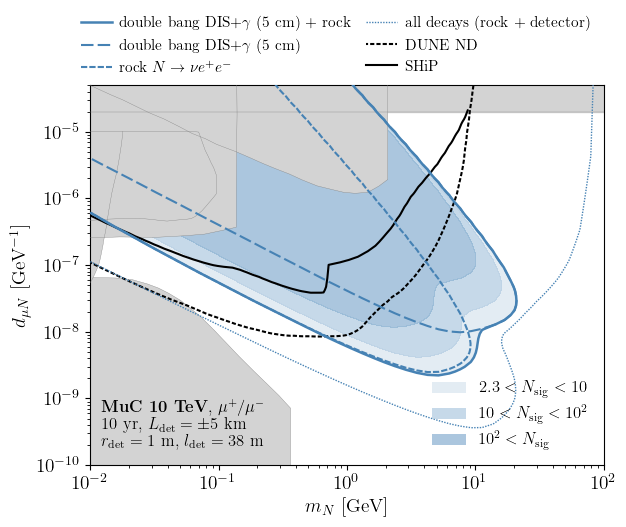

In [9]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from HNLimits import plot_tools
# ---------------------------------------------------------------------------
# One styling table + one plotting routine, used by BOTH coupling figures, so
# the d_muN and d_eN figures are guaranteed to be drawn identically.
# Axes: m_N [GeV] vs d [GeV^-1].
# ---------------------------------------------------------------------------
FIGSIZE = (6.5, 5)
LIGHTENS = [0.2, 0.4, 0.6]
COLOR_MU, COLOR_E = "steelblue", "firebrick"
ref_D = distances[0]

# (key, linestyle, lw, label, which colour: "main" or "comp")
SAMPLES = [
    ("N_clean", "-",         1.8, r"double bang DIS+$\gamma$ (5 cm) + rock", "main"),
    ("N_dis",   (0, (6, 2)), 1.5, r"double bang DIS+$\gamma$ (5 cm)", "main"),
    ("N_ee",    (0, (3, 1)), 1.5, r"rock $N \to \nu e^+e^-$",            "comp"),
    ("N_tot",   (0, (1, 1)), 1.0, r"all decays (rock + detector)",             "main"),
]

TINY = 1e-300


def lower_envelope(curves, n=400):
    """Lowest coupling covered by ANY of the given closed regions.

    Each curve is a closed (x, y) boundary; for every mass we take the smallest
    y reached by any segment of any curve, i.e. the bottom edge of the union of
    the regions. Interpolation is done in log-log, where these boundaries are
    close to piecewise linear.
    """
    xmin = min(c[0].min() for c in curves)
    xmax = max(c[0].max() for c in curves)
    xg = np.geomspace(xmin, xmax, n)
    lxg = np.log(xg)
    env = np.full(n, np.inf)
    for x, y in curves:
        lx, ly = np.log(x), np.log(y)
        for i in range(len(x) - 1):
            x0, x1 = lx[i], lx[i + 1]
            if x0 == x1:
                continue
            m = (lxg >= min(x0, x1)) & (lxg <= max(x0, x1))
            if m.any():
                t = (lxg[m] - x0) / (x1 - x0)
                env[m] = np.minimum(env[m], np.exp(ly[i] + t * (ly[i + 1] - ly[i])))
    ok = np.isfinite(env)
    return xg[ok], env[ok]


def plot_dipole_reach(S, ylabel, draw_limits, outfile, main_color, comp_color,
                      projections=()):
    """Sensitivity in the (m_N, d) plane for one coupling.

    projections: iterable of (list_of_files, label, linestyle), drawn in black
    with a SINGLE legend entry per group. A group holding several files is
    merged into one line tracing the bottom edge of the combined region.

    NOTE: contours are taken on log N, not N.  The decay-dominated upper edge
    falls like exp(-alpha d^2) with alpha ~ m^4, so N changes by orders of
    magnitude between adjacent grid points; interpolating linearly in N (the
    matplotlib default) misplaces that edge by several percent, by a different
    amount at each mass -> the jagged upper edge.  log N is nearly linear in
    d^2, so linear interpolation of it is accurate (~0.1%).
    """
    cols = [dlim.lighten_color(main_color, x) for x in LIGHTENS]
    fig, ax = pt.std_fig(figsize=FIGSIZE)
    draw_limits(ax)

    logN = {k: np.log(np.maximum(S[k], TINY)) for k, *_ in SAMPLES}

    ax.contourf(mN_2D, d_2D, logN["N_clean"],
                levels=[np.log(2.3), np.log(10), np.log(1e2), np.inf],
                colors=cols, zorder=0, alpha=0.75)
    for key, ls, lw, _, role in SAMPLES:
        ax.contour(mN_2D, d_2D, logN[key], levels=[np.log(2.3)],
                   colors=[main_color if role == "main" else comp_color],
                   linestyles=[ls], linewidths=[lw], zorder=5)

    # external projections, one legend entry per group
    proj_handles = []
    for files, label, ls in projections:
        curves = []
        for f in files:
            x, y = np.genfromtxt(f, unpack=True)
            curves.append(plot_tools.get_ordered_closed_region((x, y),
                                                              logx=True, logy=True))
        if len(curves) > 1:      # merge into the bottom edge of the union
            curves = [lower_envelope(curves)]
        for x, y in curves:
            ax.plot(x, y, color="black", ls=ls, lw=1.5, zorder=4)
        proj_handles.append(Line2D([0], [0], color="black", ls=ls, lw=1.5, label=label))

    line_handles = [
        Line2D([0], [0], color=(main_color if role == "main" else comp_color),
               lw=lw, ls=ls, label=lab)
        for _, ls, lw, lab, role in SAMPLES
    ] + proj_handles
    region_handles = [
        Patch(facecolor=cols[0], edgecolor="none", alpha=0.75,
              label=r"$2.3 < N_{\rm sig} < 10$"),
        Patch(facecolor=cols[1], edgecolor="none", alpha=0.75,
              label=r"$10 < N_{\rm sig} < 10^2$"),
        Patch(facecolor=cols[2], edgecolor="none", alpha=0.75,
              label=r"$10^2 < N_{\rm sig}$"),
    ]

    leg_lines = ax.legend(region_handles, [h.get_label() for h in region_handles],
                          loc="lower right",
                          facecolor="white", framealpha=0.75, fontsize=12,
                          ncol=1, edgecolor="none")
    ax.add_artist(leg_lines)
    ax.legend(line_handles, [h.get_label() for h in line_handles],
              loc=(-0.03, 1.01), frameon=False, facecolor="white",
              framealpha=0.75, fontsize=11, ncol=2,
              handletextpad=0.5, columnspacing=1.0)

    annot = (fr"\noindent\textbf{{MuC 10 TeV}}, $\mu^+/\mu^-$\\"
             fr"10 yr, $L_{{\rm det}} = \pm{ref_D/1e5:.0f}$ km\\"
             fr"$r_{{\rm det}} = {DET_R/100:.0f}$ m, $l_{{\rm det}} = {L_fid/100:.0f}$ m")
    ax.annotate(annot, xy=(0.02, 0.04), xycoords="axes fraction", fontsize=12,
                ha="left", va="bottom", multialignment="left")

    ax.tick_params(axis="both", labelsize=14)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(1e-2, 1e2)
    ax.set_ylim(1e-10, 5e-5)
    ax.set_xlabel(r"$m_N$ [GeV]", fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    fig.savefig(outfile, bbox_inches="tight", dpi=300)

    for key, name in (("N_tot", "single photon"), ("N_clean", "combined DV")):
        lower, _ = hnl.exclusion_band(m_N_grid, d_grid, S[key], n_events=2.3)
        i = int(np.nanargmin(lower))
        print(f"  {name:14s}: best reach d ~ {np.nanmin(lower):.2e} GeV^-1 "
              f"at m_N = {m_N_grid[i]:.3g} GeV")
    return fig, ax


DD = "dipole_limits_data"
print("d_muN:")
plot_dipole_reach(
    scan_results[ref_D],
    r"$d_{\mu N}$ [GeV$^{-1}$]",
    lambda a: dlim.plot_existing_limits(a, x_scale=1e-3, miniboone=False,
                                        annotate=False, limit_color="gray",
                                        facecolor="lightgray"),
    "plots/hnl_dipole_sensitivity_dmu.pdf",
    COLOR_MU, COLOR_MU,
    projections=[
        ([f"{DD}/DUNE_HE_dmu.dat"], "DUNE ND", (1, (2, 1))),
        ([f"{DD}/SHiP_main_dmu.dat", f"{DD}/SHiP_ECC_dmu.dat"], "SHiP", "-"),
    ],
)


### Electron coupling: $(m_N,\ d_{eN})$

The same figure for the electron coupling, drawn by the same routine so the two
are directly comparable. Note the much sparser existing-constraint landscape —
Borexino and SN1987A, with the SHiP projections dashed, and no NOMAD/CHARM-II
analogue.

d_eN:


  single photon : best reach d ~ 4.23e-10 GeV^-1 at m_N = 6.26 GeV
  combined DV   : best reach d ~ 2.54e-09 GeV^-1 at m_N = 3.49 GeV


(<Figure size 650x500 with 1 Axes>,
 <Axes: xlabel='$m_N$ [GeV]', ylabel='$d_{e N}$ [GeV$^{-1}$]'>)

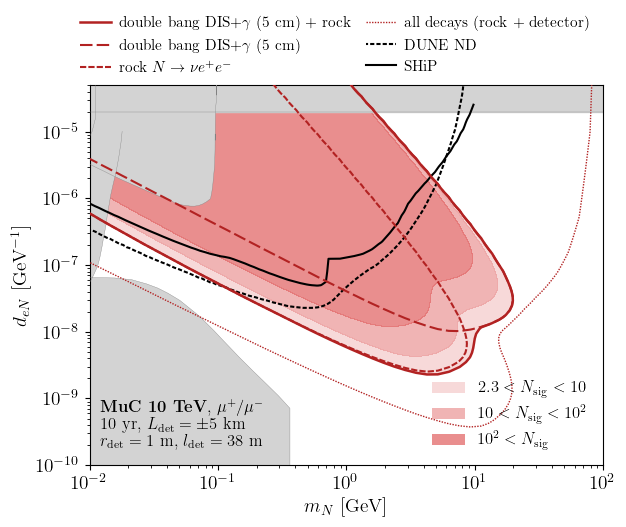

In [10]:
print("d_eN:")
plot_dipole_reach(
    scan_e,
    r"$d_{e N}$ [GeV$^{-1}$]",
    lambda a: dlim.plot_existing_limits_de(a, x_scale=1e-3, annotate=False,
                                           limit_color="gray",
                                           facecolor="lightgray"),
    "plots/hnl_dipole_sensitivity_de.pdf",
    COLOR_E, COLOR_E,
    projections=[
        ([f"{DD}/DUNE_HE_de.dat"], "DUNE ND", (1, (2, 1))),
        ([f"{DD}/SHIP_main_de.dat", f"{DD}/SHIP_ECC_de.dat"], "SHiP", "-"),
    ],
)


## 5. Scattering on electrons

The dipole portal also upscatters neutrinos on the **electrons** of the gas,
$\nu\, e^- \to N\, e^-$ (Jodlowski & Trojanowski, arXiv:2011.04751, Eq. (A.10) — the
same exact formula used to pin the coupling convention in `validate_dipole_xsecs.py`).
The observable is a **single hard electron recoil**, identical in topology to SM
neutrino–electron elastic scattering, which is therefore the irreducible background:

- **SM**: $\bar\nu_\mu\, e^-$ and $\nu_e\, e^-$ elastic scattering of the two $\mu^+$-beam
  components (`mint.xsecs.nue_elastic_dsigma_dy`);
- **New physics**: only the $\bar\nu_\mu$ flux upscatters via $d_{\mu N}$; the produced
  $N$ is long-lived at the relevant couplings ($\gamma c\tau \sim 0.5$ km at
  $m_N = 1$ GeV, $d = 10^{-7}$) and escapes, leaving just the recoil.

The electron-target kinematics are unforgiving: producing $m_N$ requires
$E_\nu > m_N^2/2m_e \simeq 1\ {\rm TeV} \times (m_N/{\rm GeV})^2$, so only the
multi-TeV tail of the flux participates and the channel shuts off above
$m_N \simeq \sqrt{2 m_e E_\nu^{\rm max}} \approx 2.2$ GeV. In return, the dipole's
$1/t^2$ photon pole piles the signal at **low recoil energies**, where the SM rate per
bin is smallest — the shape handle the $\chi^2$ exploits.

**Statistical treatment**: Asimov data (= SM), Gaussian bin-by-bin statistics, one
bin-to-bin-**correlated** normalization nuisance with $\sigma_{\rm norm} = 1\%$
(profiled analytically), limit at $\Delta\chi^2 = 2.71$ (90% CL).

**Both beams.** The analysis is repeated for the $\mu^-$ beam ($\nu_\mu + \bar\nu_e$
fluxes, mirrored detector 5 km upstream): the dipole signal now rides on the $\nu_\mu$
flux, while the SM background is smaller — $\sigma(\bar\nu_e e) \simeq \sigma(\nu_e e)/2.4$
(the $C_{LL} \leftrightarrow C_{LR}$ swap) — so the $\mu^-$ beam sets the stronger limit.

In [11]:
from mint import xsecs

# nu_e flux of the mu+ beam: exact reweighting of the same vegas sample
sim_nue = sim.reweighted_copy(nuflavor="nue")
sim_nue.place_muons_on_lattice(lattice=ring, direction="clockwise")

# neutrinos ray-traced through the gas volume (electron targets live in the gas)
det_vol = dt.CylinderVolume(gas, radius=DET_R, length=DET_L,
                            center=(0, 0, DIST + DET_L / 2), name="HPGAr")

def gas_flux(s):
    _, ch = det_vol.intersect(*dt.sim_rays(s))
    m_ = ch > 0
    # per-detector spectra: one detector, 10 years (injections_per_year carries x20)
    return (np.asarray(s.pnu["E"])[m_],
            s.weights.flatten()[m_] * injections_per_year / N_DETECTORS, ch[m_])

E_mub, w_mub, ch_mub = gas_flux(sim)
E_e, w_e, ch_e = gas_flux(sim_nue)

n_electron = gas.N * gas.Z / gas.A   # electrons / cm^3 in the gas
print(f"electron column (full length): {n_electron * DET_L:.2e} e-/cm^2")
print(f"numubar through the gas: {w_mub.sum():.3e} /yr | nue: {w_e.sum():.3e} /yr")

# Electron-recoil analysis binning
TE_MIN, TE_MAX, N_BINS = 100.0, 5e3, 25    # GeV (detector threshold Te > 1 GeV)
Te_edges = np.geomspace(TE_MIN, TE_MAX, N_BINS + 1)
Te_c = np.sqrt(Te_edges[1:] * Te_edges[:-1])


def recoil_spectrum(E, w, ch, dsigma_dTe, n_nodes=8):
    """Electron-recoil spectrum [events/bin/yr]: per-bin integral of dsigma/dTe
    (a callable of (Te, E)) folded with the flux and per-event electron column."""
    counts = np.zeros(N_BINS)
    for i, (lo, hi) in enumerate(zip(Te_edges[:-1], Te_edges[1:])):
        Te = np.geomspace(lo, hi, n_nodes)
        ds = dsigma_dTe(Te[:, None], E[None, :])          # (nodes, events)
        sigma_bin = np.trapezoid(ds, Te, axis=0)          # cm^2 per event
        counts[i] = np.sum(w * ch * n_electron * sigma_bin)
    return counts


def sm_es_dsigma_dTe(nuf):
    """SM nu-e elastic dsigma/dTe [cm^2/GeV] (y = Te/E, dsigma/dTe = dsigma/dy / E)."""
    def f(Te, E):
        return xsecs.nue_elastic_dsigma_dy(Te / E, E, nuf) / E
    return f


# SM backgrounds and the NP template at a reference coupling (NP ~ d^2)
M_BENCH = 0.1      # GeV
D_REF = 1e-6       # GeV^-1 (template reference; rescaled analytically)

sm_mub = recoil_spectrum(E_mub, w_mub, ch_mub, sm_es_dsigma_dTe("numubar"))
sm_nue = recoil_spectrum(E_e, w_e, ch_e, sm_es_dsigma_dTe("nue"))
sm_tot = sm_mub + sm_nue

np_ref = recoil_spectrum(
    E_mub, w_mub, ch_mub,
    lambda Te, E: hnl.dipole_electron_dsigma_dTe(Te, E, M_BENCH, D_REF))

print(f"SM nu-e ES events/yr (Te > {TE_MIN:g} GeV): "
      f"numubar-e {sm_mub.sum():.3e}, nue-e {sm_nue.sum():.3e}")
print(f"NP (m_N = {M_BENCH:g} GeV, d = {D_REF:.0e}): {np_ref.sum():.3e} events/yr")

electron column (full length): 8.57e+24 e-/cm^2
numubar through the gas: 1.814e+19 /yr | nue: 1.823e+19 /yr


SM nu-e ES events/yr (Te > 100 GeV): numubar-e 3.268e+05, nue-e 2.052e+06
NP (m_N = 0.1 GeV, d = 1e-06): 2.962e+03 events/yr


In [12]:
# ---------------- mu- beam: nu_mu and nuebar fluxes, detector 5 km upstream ----------------
# mu- -> e- nu_mu nu_e-bar: the counter-circulating beam. The same dipole d_{mu N}
# now upscatters the nu_mu flux, while the SM background swaps to nu_mu-e + nuebar-e
# -- and sigma(nuebar e) ~ sigma(nue e)/2.4 (the C_LL <-> C_LR swap), so the
# background is lower for the same signal.
sim_numu = sim.reweighted_copy(nuflavor="numu")
sim_numu.place_muons_on_lattice(lattice=ring, direction="counter-clockwise")
sim_nueb_sim = sim.reweighted_copy(nuflavor="nuebar")
sim_nueb_sim.place_muons_on_lattice(lattice=ring, direction="counter-clockwise")

det_vol_m = dt.CylinderVolume(gas, radius=DET_R, length=DET_L,
                              center=(0, 0, -(DIST + DET_L / 2)), name="HPGAr_upstream")

def gas_flux_m(s):
    _, ch = det_vol_m.intersect(*dt.sim_rays(s))
    m_ = ch > 0
    # per-detector spectra: one detector, 10 years
    return (np.asarray(s.pnu["E"])[m_],
            s.weights.flatten()[m_] * injections_per_year / N_DETECTORS, ch[m_])

E_mu, w_mu, ch_mu = gas_flux_m(sim_numu)
E_eb, w_eb, ch_eb = gas_flux_m(sim_nueb_sim)
print(f"numu through the upstream gas: {w_mu.sum():.3e} /yr | nuebar: {w_eb.sum():.3e} /yr")

sm_mu = recoil_spectrum(E_mu, w_mu, ch_mu, sm_es_dsigma_dTe("numu"))
sm_nueb = recoil_spectrum(E_eb, w_eb, ch_eb, sm_es_dsigma_dTe("nuebar"))
sm_tot_m = sm_mu + sm_nueb

np_ref_m = recoil_spectrum(
    E_mu, w_mu, ch_mu,
    lambda Te, E: hnl.dipole_electron_dsigma_dTe(Te, E, M_BENCH, D_REF))

print(f"SM (mu- beam, Te > {TE_MIN:g} GeV): numu-e {sm_mu.sum():.3e}, nuebar-e {sm_nueb.sum():.3e} /yr")
print(f"NP (m_N = {M_BENCH:g} GeV, d = {D_REF:.0e}): {np_ref_m.sum():.3e} events/yr")

numu through the upstream gas: 1.805e+19 /yr | nuebar: 1.805e+19 /yr


SM (mu- beam, Te > 100 GeV): numu-e 4.097e+05, nuebar-e 7.732e+05 /yr
NP (m_N = 0.1 GeV, d = 1e-06): 2.953e+03 events/yr


90% CL limit at m_N = 0.1 GeV: mu+ beam d < 7.30e-07 | mu- beam d < 6.80e-07 GeV^-1


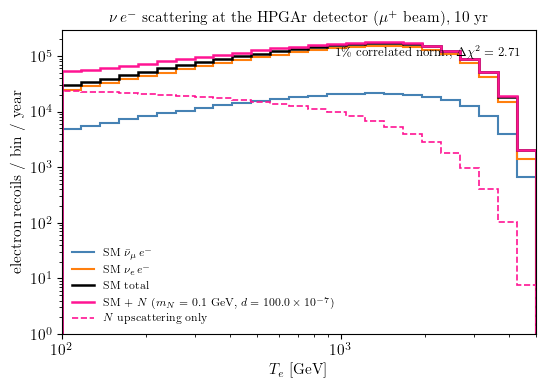

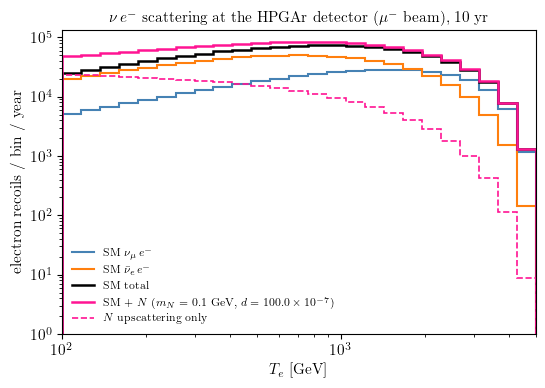

In [13]:
# ---------------- chi2 with a 1% bin-to-bin-correlated normalization ----------------
SIGMA_NORM = 1e-6

def chi2_profiled(s, b, sigma_norm=SIGMA_NORM):
    """Asimov chi2, profiling one correlated normalization nuisance analytically:
        chi2(alpha) = sum (s_i + alpha b_i)^2 / b_i + (alpha/sigma)^2
        => chi2_min = sum s_i^2/b_i - (sum s_i)^2 / (sum b_i + 1/sigma^2).
    """
    good = b > 0
    s, b = s[good], b[good]
    return np.sum(s**2 / b) - np.sum(s)**2 / (np.sum(b) + 1.0 / sigma_norm**2)


def d_limit(np_template, d_ref, sm, dchi2=2.71):
    """90% CL limit on d: chi2 scales exactly as (d/d_ref)^4."""
    chi2_ref = chi2_profiled(np_template, sm)
    if chi2_ref <= 0:
        return np.nan
    return d_ref * (dchi2 / chi2_ref) ** 0.25


d_lim_bench = d_limit(np_ref, D_REF, sm_tot)
d_lim_bench_m = d_limit(np_ref_m, D_REF, sm_tot_m)
print(f"90% CL limit at m_N = {M_BENCH:g} GeV: "
      f"mu+ beam d < {d_lim_bench:.2e} | mu- beam d < {d_lim_bench_m:.2e} GeV^-1")

# ---------------- spectrum plot at the benchmark ----------------
# d_show = d_lim_bench
d_show = 1e-5
np_show = np_ref * (d_show / D_REF) ** 2

fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(sm_mub, Te_edges, color="steelblue", lw=1.5, label=r"SM $\bar\nu_\mu\, e^-$")
ax.stairs(sm_nue, Te_edges, color="tab:orange", lw=1.5, label=r"SM $\nu_e\, e^-$")
ax.stairs(sm_tot, Te_edges, color="black", lw=1.8, label="SM total")
ax.stairs(sm_tot + np_show, Te_edges, color="deeppink", lw=1.8,
          label=rf"SM + $N$ ($m_N = {M_BENCH:g}$ GeV, $d = {d_show*1e7:.1f}\times 10^{{-7}}$)")
ax.stairs(np_show, Te_edges, color="deeppink", lw=1.2, ls="--",
          label=r"$N$ upscattering only")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(TE_MIN, TE_MAX)
ax.set_ylim(1, None)
ax.set_xlabel(r"$T_e$ [GeV]")
ax.set_ylabel(r"electron recoils / bin / year")
ax.set_title(r"$\nu\,e^-$ scattering at the HPGAr detector ($\mu^+$ beam), 10 yr", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
ax.annotate(rf"1\% correlated norm., $\Delta\chi^2 = 2.71$",
            xy=(0.97, 0.95), xycoords="axes fraction", ha="right", va="top", fontsize=9)
fig.savefig("plots/hnl_dipole_electron_recoil_spectrum.pdf", bbox_inches="tight", dpi=300)

# ---------------- mu- beam spectrum ----------------
np_show_m = np_ref_m * (d_show / D_REF) ** 2

fig, ax = pt.std_fig(figsize=(6, 4))
ax.stairs(sm_mu, Te_edges, color="steelblue", lw=1.5, label=r"SM $\nu_\mu\, e^-$")
ax.stairs(sm_nueb, Te_edges, color="tab:orange", lw=1.5, label=r"SM $\bar\nu_e\, e^-$")
ax.stairs(sm_tot_m, Te_edges, color="black", lw=1.8, label="SM total")
ax.stairs(sm_tot_m + np_show_m, Te_edges, color="deeppink", lw=1.8,
          label=rf"SM + $N$ ($m_N = {M_BENCH:g}$ GeV, $d = {d_show*1e7:.1f}\times 10^{{-7}}$)")
ax.stairs(np_show_m, Te_edges, color="deeppink", lw=1.2, ls="--",
          label=r"$N$ upscattering only")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(TE_MIN, TE_MAX)
ax.set_ylim(1, None)
ax.set_xlabel(r"$T_e$ [GeV]")
ax.set_ylabel(r"electron recoils / bin / year")
ax.set_title(r"$\nu\,e^-$ scattering at the HPGAr detector ($\mu^-$ beam), 10 yr", fontsize=11)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.savefig("plots/hnl_dipole_electron_recoil_spectrum_mum.pdf", bbox_inches="tight", dpi=300)

In [14]:
# ---------------- limit vs mass ----------------
m_scan = np.geomspace(0.05, 2.2, 24)
d_lims = np.array([
    d_limit(recoil_spectrum(E_mub, w_mub, ch_mub,
                            lambda Te, E, m=m: hnl.dipole_electron_dsigma_dTe(Te, E, m, D_REF)),
            D_REF, sm_tot)
    for m in m_scan
])
d_lims_m = np.array([
    d_limit(recoil_spectrum(E_mu, w_mu, ch_mu,
                            lambda Te, E, m=m: hnl.dipole_electron_dsigma_dTe(Te, E, m, D_REF)),
            D_REF, sm_tot_m)
    for m in m_scan
])


mu+ beam: best limit d < 7.28e-07 GeV^-1 at m_N = 50 MeV
mu- beam: best limit d < 6.78e-07 GeV^-1 at m_N = 50 MeV


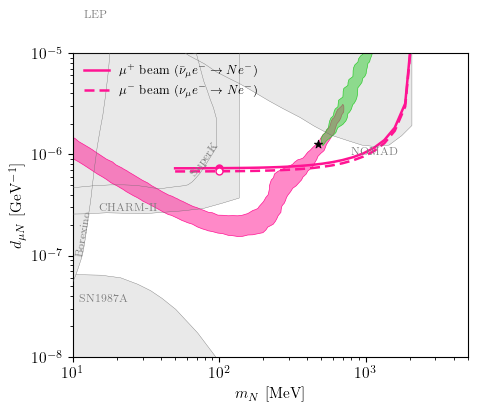

In [15]:

fig, ax = pt.std_fig(figsize=(5, 4))
l1, l2 = dlim.plot_existing_limits(ax)
ax.plot(m_scan * 1e3, d_lims, color="deeppink", lw=1.8,
        label=r"$\mu^+$ beam ($\bar\nu_\mu e^- \to N e^-$)")
ax.plot(m_scan * 1e3, d_lims_m, color="deeppink", lw=1.8, ls=(0, (4, 2)),
        label=r"$\mu^-$ beam ($\nu_\mu e^- \to N e^-$)")
ax.scatter([M_BENCH * 1e3], [d_lim_bench], color="deeppink", marker="o", s=25, zorder=6)
ax.scatter([M_BENCH * 1e3], [d_lim_bench_m], color="deeppink", marker="o", s=25,
           facecolor="white", zorder=6)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(10, 5e3)
ax.set_ylim(1e-8, 1e-5)
ax.set_xlabel(r"$m_N$ [MeV]")
ax.set_ylabel(r"$d_{\mu N}$ [GeV$^{-1}$]")
ax.legend(frameon=False, fontsize=9, loc="upper left")
fig.savefig("plots/hnl_dipole_electron_scattering_limit.pdf", bbox_inches="tight", dpi=300)

for lab, dl in [("mu+ beam", d_lims), ("mu- beam", d_lims_m)]:
    i_best = np.nanargmin(dl)
    print(f"{lab}: best limit d < {np.nanmin(dl):.2e} GeV^-1 at m_N = {m_scan[i_best]*1e3:.0f} MeV")

## 6. Notes

- **Production** is the leading-log coherent Primakoff estimate
  (`hnl_tools.dipole_coherent_xsec`); at these masses ($\lesssim 2$ GeV) and TeV
  energies coherence holds, but the $\mathcal{O}(1)$ normalization and the incoherent
  contribution are approximate. `hnl_tools.DarkNewsPortal(coupling_kind="dipole")`
  provides the full coherent + nucleon-elastic cross section for cross-checks
  (see `hnl_darknews_sensitivity.ipynb`).
- **Decay** $N\to\nu\gamma$ is fully visible (single photon); no branching
  penalty, but the single-photon final state has no reconstructable production vertex
  in the rock case — a photon $p_T$ cut (`PT_MIN`) is the available handle, kept off
  here to match the mixing-portal figure.
- **Backgrounds** assumed zero (2.3 events = 90% CL), as in the mixing study.
- The MINERvA constraints from the `nu-dipole` analysis are deliberately not shown.

### Cross-section validation (`validate_dipole_xsecs.py`)

The production estimates were validated against exact calculations
(DarkNews dev branch + CT18NNLO via the `parton` backend):

- **Coupling convention** (pinned to ~2%): DarkNews' dipole vertex coupling is
  $T_{ij} = \mu_{\rm tr}/2$ and *equals our* $d$ — confirmed by comparing DarkNews
  proton-elastic on hydrogen against the exact Eq. (A.10) of arXiv:2011.04751
  (ratio $= 1/4$ exactly as predicted). `DarkNewsPortal` now applies this factor
  internally.
- **Coherent** (single-$\gamma$ and rock $\ell^+\ell^-$ curves): exact/analytic
  $= 0.8$–$1.5$ for $m_N = 0.1$–$2$ GeV at $0.5$–$3$ TeV. The log-accuracy
  coefficient is 4 (Magill et al., 1803.03262 Eq. 2) but the nuclear form factor
  erodes it; the default `coeff = 2` reproduces the exact result to $\pm 50\%$.
- **DIS** (dashed curve): exact/leading-log $= 1.05$–$1.1$ at valence-dominated
  energies ($E \sim 250$ GeV, $m_N \lesssim 1$ GeV) — independently confirming both
  the partonic coefficient and the convention — growing to $\sim 2.5\times$
  **conservative** at 3 TeV (uncounted sea quarks), and overestimating by
  $2$–$7\times$ only near the high-mass threshold ($m_N \sim 20$ GeV at
  $E \lesssim 1$ TeV).

- **Electron scattering** (Section 5): Eq. (A.10) verified *independently* at the
  amplitude level — explicit Dirac spinors + the dipole vertex reproduce it to
  $5 \times 10^{-9}$ at random phase-space points, with the same machinery anchored on
  $\Gamma(N\to\nu\gamma) = d^2 m^3/4\pi$, and the $m_N \to 0$ limit reproducing the
  Vogel–Engel magnetic-moment formula with $\mu_\nu = 2d$.

Since the signal scales as $d^2$–$d^4$, these accuracies correspond to
$\lesssim 25\%$ shifts of the reach contours in $d$.